# Thesis full Implementation

In [1]:
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [2]:
import sys
print(sys.executable)
print(sys.path)

/home/sai/Documents/School/AY2025-2026/T2/THSCE03/THES2/.venv/bin/python3
['/home/sai/.local/share/uv/python/cpython-3.13.11-linux-x86_64-gnu/lib/python313.zip', '/home/sai/.local/share/uv/python/cpython-3.13.11-linux-x86_64-gnu/lib/python3.13', '/home/sai/.local/share/uv/python/cpython-3.13.11-linux-x86_64-gnu/lib/python3.13/lib-dynload', '', '/home/sai/Documents/School/AY2025-2026/T2/THSCE03/THES2/.venv/lib/python3.13/site-packages']


In [3]:
import fullPipe

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import box_man

from cv2.typing import MatLike
from math import ceil
from jdeskew.estimator import get_angle
from jdeskew.utility import rotate
from skimage.filters import threshold_sauvola

2026-01-28 08:28:33.039571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 08:28:33.039832: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-28 08:28:33.076523: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 08:28:33.813847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [4]:
def show_img(img: MatLike, title:str = ""):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.show()

## Char recognition model

In [5]:
from keras.models import load_model
model_path = './model/handwriting_MNIST.keras'
loaded_model = load_model(model_path)

# loaded_model.load_weights(model_path)

# Helper functions

In [6]:
# Don't dilate template characters
word_dict = {
    0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z',
    26:'a',27:'b',28:'c',29:'d',30:'e',31:'f',32:'g',33:'h',34:'i',35:'j',36:'k',37:'l',38:'m',39:'n',40:'o',41:'p',42:'q',43:'r',44:'s',45:'t',46:'u',47:'v',48:'w',49:'x',50:'y',
    # 51:'z'
}


In [7]:
def plot_imgs(imgs: list, n_row, n_col, save_img=False):
    plt.close('all')  # Close any existing figures FIRST
    
    _, axs = plt.subplots(n_row, n_col, figsize=(12, 12))
    axs = axs.flatten()
    
    for img, ax in zip(imgs, axs):
        ax.imshow(img, cmap='gray')
        ax.axis('off')  # Optional: hide axes for cleaner look
    
    # Hide unused subplots
    for ax in axs[len(imgs):]:
        ax.axis('off')
    
    plt.tight_layout()
    if save_img: 
        plt.savefig('foo.png', bbox_inches='tight')
    plt.show()
    plt.close('all')

## Page Checking

In [8]:
def template_char_check(img: MatLike):
    
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    img = cv.bitwise_not(img)
    # img = clahe_binarization(img)
        
    img = cv.resize(img, (28, 28))
    img = img.astype('float32') / 255.0
    
    # Add channel dimension (if model expects 1 channel)
    img_predict = np.expand_dims(img, axis=-1)  # shape: (30, 30, 1)
    
    # Add batch dimension
    img_predict = np.expand_dims(img_predict, axis=0)   # shape: (1, 30, 30, 1)
    
    prediction = loaded_model.predict(img_predict)
    print(prediction)
    print(f'size: {prediction.shape[1]}')
    
    
    return img, word_dict[np.argmax(prediction)]
    # modify this such that if there is already an implementation 
    # show_img(img, 'normalized')

In [9]:
def check_page(img: MatLike):
    # ROW_SIZE = 6
    # COL2_RANGE = 11
    coords = fullPipe.box_man.Boxman(mode='check').cells
    # coords = fullPipe.box_man.Boxman().cells[:2]
    print(f'coords{len(coords)}: {coords[0]} {coords[1]}')
    # show_img(img, 'check page img')
    #add list of character ranges for each page to return the correct file path or whatever representation
    char_set = ["ABCDEFGHIJ",
                "KLMNOPQRST",
                "UVWXYZabcd",
                "efghijklmn",
                "opqrstuvwx",
                "yz",
                # "EEEEEE" # testing
                ]
    # check first two columns for the characters
    img_list = []
    first_chars = []
    print(f'check_page len coords: {len(coords)}')
    for i in range (0, len(coords)): # iterate only till 2nd row
        template_char = img[coords[i].y:coords[i].y+coords[i].h,coords[i].x:coords[i].x+coords[i].w]
        char_img, template_txt = template_char_check(template_char)
        img_list.append(char_img)
        first_chars.append(template_txt)
        
    plt.close('all')  # Close before plotting
    plot_imgs(img_list, 1, 2)
    first_chars = ''.join(first_chars)
    print(f'template_txt {first_chars}')
    
    for chars in char_set:
        if chars[0:2].lower() == first_chars.lower():
            print(f"Char set found: {chars}")
            return chars
    print("Char set not found")
    return None

## Preprocess

In [10]:
# have to check the current image first for the existing letters or character set 
# adjust this for y-z
def correct_perspective(image: MatLike, output_path: str="3_corrTab.png") -> MatLike:
    
    # char_set = {"ABCDEFGHIJ": "./template/A-J.png",
    #             "KLMNOPQRST": "./template/K-T.png",
    #             "UVWXYZabcd": "./template/U-d.png",
    #             "efghijklmn": "./template/e-n.png",
    #             "opqrstuvwx": "./template/o-x.png",
    #             "yz": "./template/y-z.png"}
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    thresh = cv.adaptiveThreshold(gray, 255,
                                   cv.ADAPTIVE_THRESH_MEAN_C,
                                   cv.THRESH_BINARY_INV, 15, 10)
    cnts, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    corrected = image
    
    if cnts:
        c = max(cnts, key=cv.contourArea)
        epsilon = 0.02 * cv.arcLength(c, True)
        approx = cv.approxPolyDP(c, epsilon, True)
        if len(approx) == 4:
            src_points = np.float32([p[0] for p in approx])
            s = src_points.sum(axis=1)
            rect = np.zeros((4, 2), dtype="float32")
            rect[0] = src_points[np.argmin(s)]
            rect[2] = src_points[np.argmax(s)]
            diff = np.diff(src_points, axis=1)
            rect[1] = src_points[np.argmin(diff)]
            rect[3] = src_points[np.argmax(diff)]
            
            # Calculate dimensions based on top edge
            top_width = np.linalg.norm(rect[1] - rect[0])
            left_height = np.linalg.norm(rect[3] - rect[0])
            right_height = np.linalg.norm(rect[2] - rect[1])
            avg_height = (left_height + right_height) / 2

            # 100px height per character
            # if num_enclosed <= 12: # if number of cells is less than 60 supposedly it is assumed it is yz worksheet
            # # have to fix this tho
            # # Scale to desired height
            #     scale = 200 / avg_height
            #     width = int(top_width * scale)
            #     height = 200
            # else:
            height, width = thresh.shape
            width_ratio = width / height
            height = 1000
            width = ceil(width_ratio * 1000)

            dst_points = np.float32([[0, 0], [width-1, 0],
                                     [width-1, height-1], [0, height-1]])
            M = cv.getPerspectiveTransform(rect, dst_points)
            corrected = cv.warpPerspective(image, M, (width, height))

            
                
            # Bottom points stay at same y-level, expanded horizontally
            dst_points = np.float32([[0, 0], [width-1, 0],
                                     [width-1, height-1], [0, height-1]])
            M = cv.getPerspectiveTransform(rect, dst_points)
            corrected = cv.warpPerspective(image, M, (width, height))
    
    cv.imwrite(output_path, corrected)
    
    print(f"✅ Perspective correction done -> {output_path}")
    return corrected

In [11]:
# preprocess isolated charcter
def preproc_char_iso(img: MatLike, type=''):
    # show_img(img, 'preproc_char_iso input')
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # Denoise
    img = cv.fastNlMeansDenoising(img, h=10)
    
    # Sauvola thresholding
    window_size = 25
    thresh_sauvola = threshold_sauvola(img, window_size=window_size, k=0.1) 
    img = img > thresh_sauvola
    
    # Convert boolean to uint8 (0 and 255)
    img = img.astype(np.uint8) * 255
    
    # Invert so character is white on black
    img = cv.bitwise_not(img)

    # dilate expects white fg and black bg
    if type.strip() == 'hw':
        kernel = np.ones((12, 12), np.uint8)
        img = cv.dilate(img, kernel, iterations=1)
        
        kernel = np.ones((3, 3), np.uint8)
        # Apply erosion
        img = cv.erode(img, kernel, iterations=1)
    
    # Crop to bounding box
    # coords = cv.findNonZero(img)
    # if coords is not None:
    #     x, y, w, h = cv.boundingRect(coords)
    #     img = img[y:y+h, x:x+w]
    
    # Add padding
    pad = 10
    img = cv.copyMakeBorder(img, pad, pad, pad, pad, 
                            cv.BORDER_CONSTANT, value=0)
    
    # Resize to square
    # img = cv.resize(img, (28, 28))
    
    # invert again to get white bg and black fg
    img = cv.bitwise_not(img)
    # show_img(img, 'preproc_char_iso')
    
    return img

In [12]:
def resize_cr(img: MatLike):
    return cv.resize(img, (28, 28))

In [13]:
def img_format(img: MatLike) -> MatLike: # formatting for character recoginition
    img = img.astype('float32') / 255.0 
    # Add channel dimension (if model expects 1 channel)
    formatted_img = np.expand_dims(img, axis=-1)  # shape: (30, 30, 1)
    
    # Add batch dimension
    formatted_img = np.expand_dims(formatted_img, axis=0)   # shape: (1, 30, 30, 1)

    return formatted_img

In [14]:
# accepts grid removed, red line removed image
def isolate_chars(img: MatLike, boxes):
    num_row = 10
    num_col = 6
    imgs = []
    for i in range (0, num_row):
        for j in range(0, num_col):
            chr_isolated = img[boxes[i * num_col + j].y:boxes[i*num_col+j].y+boxes[i*num_col+j].h,boxes[i*num_col+j].x:boxes[i*num_col+j].x+boxes[i*num_col+j].w]
            if j == 0:    
                chr_isolated, _ = preproc_char(chr_isolated)
            else:
                chr_isolated, _ = preproc_char(chr_isolated, type='hw')
            imgs.append(chr_isolated)
                
    # for box in boxes:
    #     chr_isolated = img[box.y:box.y+box.h,box.x:box.x+box.w]
    #     chr_isolated = preproc_char
    #     imgs.append(chr_isolated)

    plot_imgs(imgs, num_row, num_col)

In [15]:
# grid cell counter helper function
def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs( np.dot(d1, d2) / np.sqrt( np.dot(d1, d1)*np.dot(d2, d2) ) )

def get_rects(bin):
    squares = []
    contours, _hierarchy = cv.findContours(bin, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        cnt_len = cv.arcLength(cnt, True)
        cnt = cv.approxPolyDP(cnt, 0.02*cnt_len, True)
        if len(cnt) == 4 and cv.contourArea(cnt) > 1000 and cv.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos( cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4] ) for i in range(4)])
            if max_cos < 0.1:
                squares.append(cnt)
    return squares
    
def count_rect(img: MatLike) -> int:
    assert img is not None, "image not found"

    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Preprocess
    blurred = cv.GaussianBlur(img, (5, 5), 0)
    _, binary = cv.threshold(blurred, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    
    # Morphological operations to clean up
    kernel = np.ones((3, 3), np.uint8)
    binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)
    binary = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel)
    
    # Get uniform rect grids
    squares = get_rects(binary)
    
    print(f"Found {len(squares)} uniform square grids")
    
    # Visualize
    # output = cv.cvtColor(image, cv.COLOR_GRAY2BGR)
    
    # show_img(binary, "binary")
    # output = cv.drawContours( image, squares, -1, (0, 255, 0), 3 )
    # show_img(output, "detected grids")

    return len(squares)

### Remove Red

In [16]:
def detect_red_flexible(image: MatLike, h_thresh=10, s_thresh=50, v_min=50):
    """
    Flexible red detection with separate thresholds
    
    Parameters:
    - h_thresh: Hue threshold (how much red vs orange/pink)
    - s_thresh: Saturation threshold (how vivid)
    - v_min: Minimum value/brightness (lower = include darker reds)
    """
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    
    # Red range 1 (0-10)
    lower_red1 = np.array([0, s_thresh, v_min])
    upper_red1 = np.array([h_thresh, 255, 255])
    mask1 = cv.inRange(hsv, lower_red1, upper_red1)
    
    # Red range 2 (170-180)
    lower_red2 = np.array([180 - h_thresh, s_thresh, v_min])
    upper_red2 = np.array([180, 255, 255])
    mask2 = cv.inRange(hsv, lower_red2, upper_red2)
    
    # Combine
    mask = cv.bitwise_or(mask1, mask2)
    result = cv.bitwise_and(image, image, mask=mask)
    
    return result, mask


In [17]:
def white_mask_then_inpaint(image, mask, dilate_iterations=2, inpaint_radius=5, method='telea'):
    """
    First replace red with white, then inpaint for smoother results
    
    Parameters:
    - image: Original image
    - mask: Binary mask of red areas (255 = red, 0 = not red)
    - dilate_iterations: How much to expand the mask
    - inpaint_radius: Radius for inpainting
    - method: 'telea' or 'ns' (Navier-Stokes)
    """
    # Step 1: Dilate mask to ensure complete coverage
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    dilated_mask = cv.dilate(mask, kernel, iterations=dilate_iterations)
    
    
    # Step 2: Replace masked area with white
    white_replaced = image.copy()
    white_replaced[dilated_mask > 0] = [255, 255, 255]
    
    
    # Step 3: Inpaint to smooth the edges
    if method == 'telea':
        inpainted = cv.inpaint(white_replaced, dilated_mask, inpaint_radius, cv.INPAINT_TELEA)
    else:  # 'ns'
        inpainted = cv.inpaint(white_replaced, dilated_mask, inpaint_radius, cv.INPAINT_NS)
    
    return inpainted, white_replaced


## Grading

In [18]:
# accepts isolated char image with black fg and white bg
# returns skewed corrected for grading
def eval_orientation(img):
    # WHITE = [255,255,255]
    # PADDING = 0
    # constant = cv.copyMakeBorder(img,PADDING,PADDING,PADDING,PADDING,cv.BORDER_CONSTANT,value=WHITE)
    # img_hdup = cv.hconcat([img, img])
    # imgs = []
    # imgs.append(img)
    angle = get_angle(img)
    # show_img(img, 'eval orientation')
    deskewed_img = rotate(img, -angle, border_value=(255, 255, 255))
    # border_value=(255, 255, 255)
    # show_img(deskewed_img, 'deskewed orientation')
    # imgs.append(deskewed_img)
    # plot_imgs(imgs,1,2)
    print(f"angle: {angle}")
    return angle, deskewed_img

In [19]:
# function returns confidence value for the expected letter and predicted letter of the model
def eval_letter_form(img, expected_char):
    # full_char_set = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    full_char_set = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
    print(f'expected char: {expected_char}')
    char_idx = full_char_set.find(expected_char)
    prediction = loaded_model.predict(img)
    print(f"predicted char: {word_dict[np.argmax(prediction)]}; actual char: {word_dict[char_idx]}")
    # print(f"predicted char: {word_dict[np.argmax(prediction)]}; actual char: {word_dict[char_idx]}")
    print(f"conf_predicted: {prediction[0][np.argmax(prediction)]:.2f}; actual_conf: {prediction[0][char_idx]:.2f}")

    return prediction[0][char_idx], word_dict[np.argmax(prediction)]

In [20]:
# expects an inverted image black background white foreground
def eval_size_align(img):
    
    if len(img.shape) == 3:
        height, width, _ = img.shape
    else:
        height, width = img.shape
    dup = img.copy()
    true_x = width
    true_y = height
    true_x2 = 0
    true_y2 = 0
    # img = cv.bitwise_not(img) 
    
    # img = cv.threshold(img,128,255,cv.THRESH_BINARY_INV)[1]
    
    # Convert to 8-bit grayscale if needed
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)  # If normalized float (0-1)
        # img = img.astype(np.uint8)  # If already in 0-255 range
        
    # Ensure it's single channel
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # thresh = cv.threshold(img,128,255,cv.THRESH_BINARY)[1]
    
    
    contours = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    contours = contours[0] if len(contours) == 2 else contours[1]
    for cntr in contours:
        x,y,w,h = cv.boundingRect(cntr)
        if cv.contourArea(cntr) < 200:
            continue
        # if filename == './dataset/dd/train_44_03054.png':
        #     print('=====Error=====')
        #     print(f'x:{x}, y:{y}, w:{w}, h:{h}')
        #     isError = True
        # if x == 0 and y == 0 and w == width and h == height:
        #     print(f'skipping {filename}')
        #     skip_cnt = skip_cnt + 1
        #     continue
        true_x = min(true_x, x)
        true_y = min(true_y, y)

        true_x2 = max(true_x2, x + w)
        true_y2 = max(true_y2, y + h)
        # cv.rectangle(dup, (x, y), (x+w, y+h), (255, 255, 255), 2)

        print(f'contourArea: {cv.contourArea(cntr)}')
        # print("x,y,w,h:",x,y,w,h)
    true_w = true_x2 - true_x
    true_h = true_y2 - true_y
    bottom = height - true_y2 # distance from bottom
    top = height - true_y
    print(f'len contours: {len(contours)}')
    cv.rectangle(dup, (true_x, true_y), (true_x+true_w, true_y+true_h), (0, 0, 0), 2)
    print("x,y,w,h:",true_x,true_y,true_w,true_h)
    print(f"returns {true_h}, {bottom}")
    show_img(dup, 'size')
    # returns size, align
    return true_h, bottom


In [21]:
def percentage_diff(n1, n2):
    if n1 == 0 or n2  == 0: # a temporary fix need to fix bounding box generation for letters to remove this
        return 0
    return abs(n1-n2)/(abs(n1+n2)/2) * 100

In [22]:
def eval_char_final(letter, template_letter, grade='2'):
    MAX_SKEW = 45 # max acceptable skew of a character
    TRUE_HEIGHT = 90 # height of template characters (px) measured in photo software
    match grade.strip().lower():
        case 'k':
            # print('Kinder rubric selected')
            letter_form_percent = 60
            line_align_percent = 40
            orientation_percent = 60
            size_percent = 50
        case '1':
            # print('Grade 1 rubric selected')
            letter_form_percent = 40
            line_align_percent = 20
            orientation_percent = 40
            size_percent = 30
        case '2':
            letter_form_percent = 20
            line_align_percent = 10
            orientation_percent = 20
            size_percent = 10   # changed from 5 to 10 despite rubric 
                                # due to parts of template may be removed when removing grid
            
    # Calculate individual statuses
    letter.letter_form_status = (100 - letter.letter_form * 100 <= letter_form_percent)
    # or (percentage_diff(letter.letter_form, template_letter.letter_form) <= letter_form_percent)
    # letter.orientation_status = abs(letter.orientation) <= abs(template_letter.orientation) or (percentage_diff(letter.orientation, template_letter.orientation) <= orientation_percent)
    # letter.orientation_status = True
    letter.orientation_status = (100 * (abs(letter.orientation) / MAX_SKEW)) <= orientation_percent
    letter.size_status = (percentage_diff(letter.size, TRUE_HEIGHT) <= size_percent) or (percentage_diff(letter.size, template_letter.size) <= size_percent)
    letter.line_align_status = abs(letter.line_align) <= abs(template_letter.line_align) or (percentage_diff(letter.line_align, template_letter.line_align) <= line_align_percent)
    
    # Combine into single grade with equal weighting
    statuses = [
        letter.letter_form_status,
        letter.orientation_status,
        letter.size_status,
        letter.line_align_status
    ]
    
    letter.overall_status = sum(statuses) / len(statuses) >= 0.5  # Returns True if 50%+ pass
    letter.overall_status = letter.size > 0 and letter.overall_status

In [23]:
# accepts perspective corrected image; no red line, grid removed
def eval_letters(img: MatLike, box, char_set):
    boxes = box.cells
    num_col = 6
    num_row = 10
    unprocessed_imgs = []
    orientation_fixed = []
    eval_preproc = []
    show_img(img, 'img @ eval_letters')
    for i in range (0, num_row):
        exp_char = char_set[i]
        char_conf_lvl = 0
        for j in range(0, num_col):
            chr_isolated = img[boxes[i * num_col + j].y:boxes[i*num_col+j].y+boxes[i*num_col+j].h,boxes[i*num_col+j].x:boxes[i*num_col+j].x+boxes[i*num_col+j].w]
            imgs.append(chr_isolated)
            # show_img(chr_isolated)
            # chr_isolated = preproc_char_iso(chr_isolated)
            # orientation_angle, fixed_orientation_img = eval_orientation(chr_isolated)
            # char_pred is used for prediction to follow model's parameters
            # chr_isolated
            if j == 0:    
                # size_img = preproc_size(chr_isolated)
                # chr_isolated = preproc_char(chr_isolated_orientation)
                chr_isolated_whitebg = preproc_char_iso(chr_isolated)
                new_letter = box_man.Letter(exp_char, boxes[i*num_col+j], is_template=True)
            else:
                # size_img = preproc_size(chr_isolated, type='hw')
                # chr_isolated = preproc_char(chr_isolated_orientation, type='hw')
                chr_isolated_whitebg = preproc_char_iso(chr_isolated, type='hw') # dilate image
                new_letter = box_man.Letter(exp_char, boxes[i*num_col+j], is_template=False)
            # preproc_char causes image color inversion so white fg and black bg
            # check orientation before inverting colors
            orientation_angle, fixed_orientation_img = eval_orientation(chr_isolated)
            
            # show_img(chr_isolated_whitebg, 'new_preproc')
            
            # Invert color then resize to 28x28
            chr_isolated = cv.bitwise_not(chr_isolated_whitebg)
            new_letter.size, new_letter.line_align = eval_size_align(chr_isolated) # evaluate size before resizing to 28x28
            chr_isolated = resize_cr(chr_isolated)
            char_pred = img_format(chr_isolated)
            # chr_isolated_orientation = eval_orientation(chr_isolated)
            # chr_isolated_orientation = eval_orientation(chr_isolated)
            orientation_fixed.append(fixed_orientation_img)
            # show_img(chr_isolated, 'chr_isolated')
            
            conf_lvl, _ = eval_letter_form(char_pred, exp_char)
            new_letter.letter_form = conf_lvl 
            new_letter.orientation = orientation_angle
            # show_img(chr_isolated)
            char_conf_lvl = char_conf_lvl + conf_lvl
            eval_preproc.append(chr_isolated)
            if j != 0:
                eval_char_final(new_letter, box.letters[i * num_col]) # evaluate non template character here
            new_letter.print_vals()
            box.letters.append(new_letter)
        print(f'{exp_char} conf level avg = {char_conf_lvl / 6}')
    # for box in boxes:
    #     chr_isolated = img[box.y:box.y+box.h,box.x:box.x+box.w]
    #     chr_isolated = preproc_char
    #     imgs.append(chr_isolated)

    plot_imgs(imgs, num_row, num_col)
    plot_imgs(orientation_fixed, num_row, num_col)
    plot_imgs(eval_preproc, num_row, num_col)
    return eval_preproc

## Output

Outputs an image that encloses with a green box on that character if pass else enclose with red if fail

In [24]:
# expects warped fix image or 3_corrTab.png
def create_result(img: MatLike, letters):
    result = img
    for letter in letters:
        # letter.print_coords()
        # print(f"isPass: {letter.isPass()}")
        box = letter.box
        x = box.x
        y = box.y
        w = box.w
        h = box.h
        if letter.is_template:
            # print("Cont..")
            continue
        if letter.isPass():
            # print("Letter passed")

            # print(f"x:{x}, y:{y}, w:{w}, h:{h}") 
            cv.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 5)
        else:
            cv.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 5)
        cv.imwrite('./final_res.png', result)
    return result


In [25]:
def create_eval_box(img: MatLike, letters, category=''):
    result = img
    for letter in letters: 
        # letter.print_coords()
        # print(f"isPass: {letter.isPass()}")
        box = letter.box
        x = box.x
        y = box.y
        w = box.w
        h = box.h
        
        if letter.is_template:
            # print("Cont..")
            continue
            
        match category.strip().lower():
            case 'orientation':
                if letter.orientation_status:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 5)         
                else:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 5)
            case 'form':
                if letter.letter_form_status:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 5)
                else:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 5)
            case 'align':
                if letter.line_align_status:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 5)
                else:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 5)
            case 'size':
                if letter.size_status:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 5)
                else:
                    cv.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 5)
                    
    cv.imwrite('./eval_box.png', result)
    return result

## Main algo

mode: all_caps

--- SIFT Alignment ---


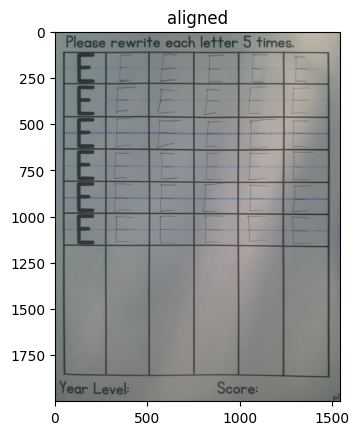

✅ SIFT alignment done -> 2_sift.png

--- Shadow Removal ---


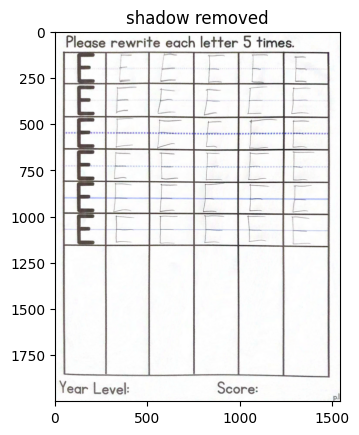

Found 40 uniform square grids

--- Perspective Correction ---
✅ Perspective correction done -> 3_corrTab.png

--- Remove Red Lines ---


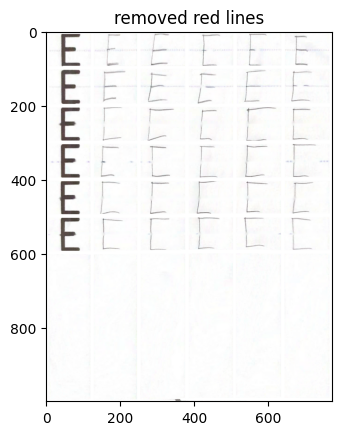

mode: check
coords2: <box_man.Box object at 0x7f871824aba0> <box_man.Box object at 0x7f871824a9e0>
check_page len coords: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[2.1295249e-05 8.1514090e-04 4.2572326e-05 3.0930229e-07 9.6600550e-01
  2.9010387e-02 2.9984869e-05 1.4159265e-04 7.4379983e-07 7.3649704e-07
  2.2569429e-03 1.3298665e-05 5.2608522e-09 4.6778746e-06 3.7825830e-06
  1.5007377e-03 4.4732598e-08 2.8022634e-05 6.7943183e-05 2.5986419e-05
  1.4901533e-06 1.5198612e-08 4.6435521e-06 1.2688712e-06 2.2752343e-05
  1.5572525e-07]]
size: 26
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[3.4210602e-06 1.1197308e-04 4.3355416e-05 3.0161512e-08 9.8295677e-01
  1.4434982e-02 5.7817588e-06 3.4416291e-05 6.3818071e-08 1.8021437e-07
  1.8948007e-03 1.3424966e-05 4.0190695e-09 1.1587019e-06 5.6978615e-06
  3.9025294e-04 4.8868149e-08 7.1008485e-06 1.4419268e-05 2.6639626e-05
  7.4744241e-07 2.6424058e-08 1.5366462e-06 1.6885564e-06 5.1463645e-05
  1.5027119e-07]]
size: 26


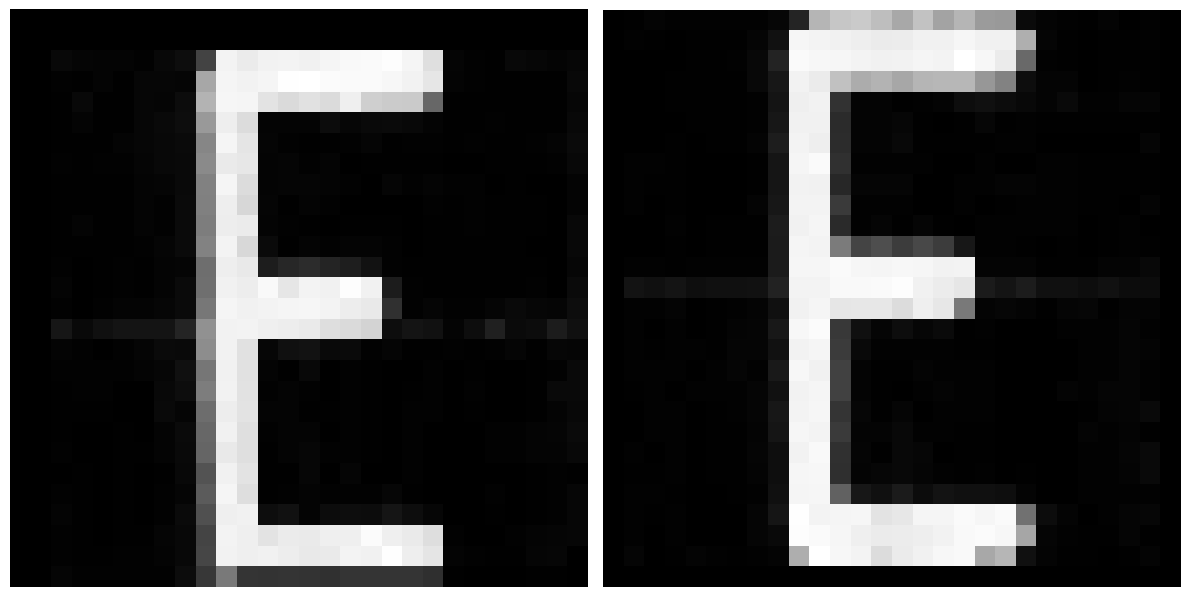

template_txt EE
Char set not found
chars: None

--- Eval Letters ---


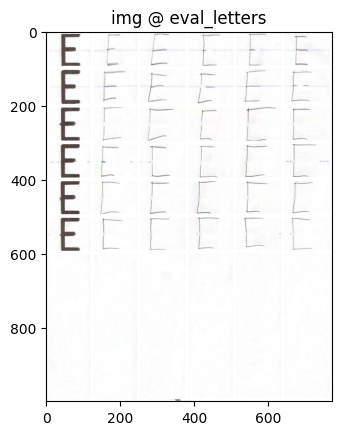

TypeError: 'NoneType' object is not subscriptable

In [45]:
template_path = "./template/A-J.png"
filled_doc_path = "./worksheets/E02.jpg"

template_img = cv.imread(template_path)
ws_img = cv.imread(filled_doc_path)

imgs = []

boxes = fullPipe.init_boxes()

print("\n--- SIFT Alignment ---")
sift_aligned = fullPipe.align_documents_sift(template_img, ws_img, "2_sift.png")

# print("\n--- Remove Red lines ---")
# result1, mask1 = detect_red_flexible(shadow_removed, h_thresh=10, s_thresh=25, v_min=25)
# inpainted1_telea, white1_telea = white_mask_then_inpaint(shadow_removed, mask1, dilate_iterations=2, inpaint_radius=3, method='telea')
# red_removed = inpainted1_telea
# # show_img(red_removed, 'red removed')

# red_removed = fullPipe.remove_colored_lines(shadow_removed, "4_no_red.png")




# red_removed = fullPip
# shadow removal function call here


print("\n--- Shadow Removal ---")
shadow_removed = fullPipe.remove_shadow(sift_aligned)
show_img(shadow_removed, "shadow removed")
cv.imwrite("removed_shadow.png", shadow_removed)

num_enclosed = count_rect(shadow_removed)
    
print("\n--- Perspective Correction ---")
# perspective_corrected = fullPipe.correct_perspective(sift_aligned, "3_corrTab.png")
perspective_corrected = correct_perspective(shadow_removed, "3_corrTab.png")



grid_removed = fullPipe.remove_grid(perspective_corrected)
# show_img(grid_removed, 'removed grid')
print("\n--- Remove Red Lines ---")
# show_img(sharpen, 'sharpened')
result2, mask2 = detect_red_flexible(grid_removed, h_thresh=10, s_thresh=25, v_min=70)
inpainted2_telea, white2_telea = white_mask_then_inpaint(grid_removed, mask2, dilate_iterations=2, inpaint_radius=3, method='telea')
image_processed = inpainted2_telea
show_img(image_processed, 'removed red lines')
cv.imwrite("./red_removed.png", image_processed)
# image_processed = fullPipe.remove_colored_lines(grid_removed, "4_no_red.png")
# image_processed = 
# show_img(image_processed, 'image_processed')

# add thresholding here before passing to eval_letters
char_set = check_page(image_processed)
print(f"chars: {char_set}")

print("\n--- Eval Letters ---")
eval_letters(image_processed, boxes, char_set) 

img_out = perspective_corrected.copy()
res_img = create_result(img_out, boxes.letters)
show_img(res_img, 'result')
# isolate_chars(image_processed, boxes.cells)

# cleaned_telea = fullPipe.clean_artifacts(inpainted1_telea)

# chr_isolated = img[box.y:box.y+box.h,box.x:box.x+box.w]
# clahe_binarization(inpainted1_telea[])

# print("\n --- Cycle Characters ---")
# cycle_characters(cleaned_telea, boxes)


# show_img(result1, 'Very Permissive - Detected Red')
# show_img(mask1, 'Mask 1')
# show_img(inpainted1_telea, 'White + Inpainted - Telea Method')
# show_img(inpainted1_ns, 'White + Inpainted - NS Method')

# print("\n--- Enhance Handwriting Final ---")
# count_enclosed(red_removed2)
# step5 = fullPipe.enhance_handwriting_final(cleaned_telea, "final_clean_strokes_white_on_black.png")



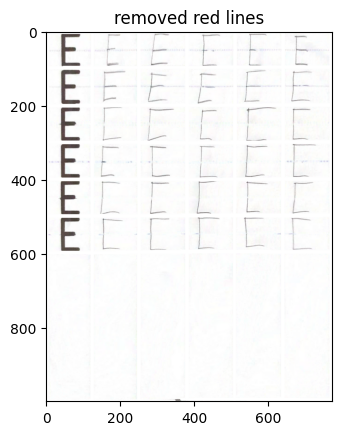

True

In [49]:
result2, mask2 = detect_red_flexible(grid_removed, h_thresh=10, s_thresh=25, v_min=80)
inpainted2_telea, white2_telea = white_mask_then_inpaint(grid_removed, mask2, dilate_iterations=1, inpaint_radius=1, method='telea')
image_processed = inpainted2_telea
show_img(image_processed, 'removed red lines')
cv.imwrite("./red_removed_new.png", image_processed)

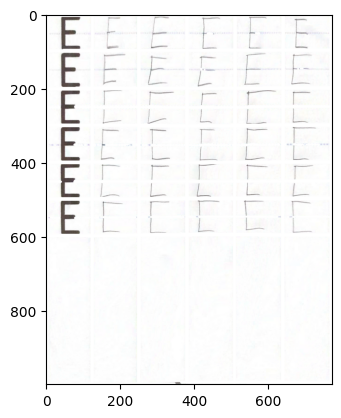

In [50]:
show_img(white2_telea)

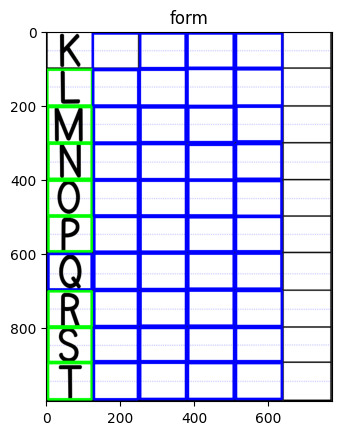

In [28]:
category = 'form'
show_img(create_eval_box(perspective_corrected.copy(), boxes.letters, category), category)

In [29]:
MAX_SKEW = 45
orientation_percent = 20
num_row = 10
num_col = 6
sel_row = 8
sel_col = 1
template_box = boxes.letters[sel_row * num_col]
template_box.print_vals()
print("=====================")
false_box = boxes.letters[num_col * sel_row + sel_col]
false_box.print_status()
false_box.print_vals()
print("=====================")
print(f"percent diff size: {percentage_diff(template_box.size, false_box.size)}")
# letter.orientation_status = (100 * abs(letter.orientation) / MAX_SKEW) <= orientation_percent
print(f"orientation info: {100 * abs(false_box.orientation / MAX_SKEW)}")

letter_form: 0.07300375401973724
orientation: 0.0
size: -115
line_align: 115
character: S
letter_form_status: True
line_align_status: True
size_status: True
orientation_status: True
letter_form: 0.9999997615814209
orientation: -0.9265442404006679
size: 92
line_align: 10
percent diff size: 1800.0
orientation info: 2.058987200890373


In [30]:
num_row = 10
num_col = 6
for i in range(0,10):
    template = boxes.letters[i * num_col]
    print(f'{template.char}: {template.orientation:.2f}')
    for j in range(1,6):
        # print(f'letter: ')
        letter = boxes.letters[i * num_col + j]
        # print(f'orientation: {letter.orientation:.2f}')
        print(f'{letter.orientation:.2f} ', end="")
        # print(f'orientation_status: {letter.orientation_status}')
    print()

K: -0.93
0.00 0.00 0.00 0.00 0.00 
L: 0.00
-0.93 0.00 0.00 0.00 0.00 
M: 0.00
-0.98 0.00 0.00 0.00 0.00 
N: 0.00
0.98 0.00 0.00 0.00 0.00 
O: 0.00
-0.93 0.00 0.00 0.00 0.00 
P: 0.00
-3.88 0.00 0.00 0.00 0.00 
Q: 0.00
9.89 0.00 0.00 0.00 0.00 
R: 0.00
4.03 0.00 0.00 0.00 0.00 
S: 0.00
-0.93 0.00 0.00 0.00 0.00 
T: 0.00
-0.93 0.00 0.00 0.00 0.00 


NameError: name 'red_removed' is not defined

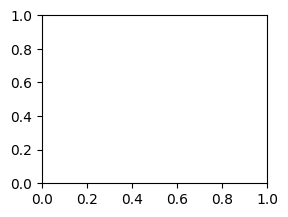

In [31]:
plt.subplot(2,2,1)
plt.imshow(red_removed, cmap='gray')
plt.title("red remove v1")

# plt.subplot(2,2,2)
# plt.imshow(red_removed2, cmap='gray')
# plt.title("red removed 2")

plt.show()

In [ ]:
# # accepts isolated character image returns a 28x28 img format same as model trained input
# # with black bg and white fg
# def preproc_size(img: MatLike, type=''):
#     if len(img.shape) == 3:
#         img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
#     # binary = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
#     #                                cv.THRESH_BINARY, 11, 2)

#     img = cv.bitwise_not(img)
#     # img = clahe_binarization(img)
#     if type.strip() == 'hw':
#         kernel = np.ones((10,10),np.uint8)
#         img = cv.dilate(img,kernel,iterations = 1)
#     img = cv.resize(img, (28, 28))
#     # img = cv.bitwise_not(img)
#     # img = img.astype('float32') / 255.0
 
    
    
#     # Add channel dimension (if model expects 1 channel)
#     # formatted_img = np.expand_dims(img, axis=-1)  # shape: (30, 30, 1)
    
#     # Add batch dimension
#     # formatted_img = np.expand_dims(formatted_img, axis=0)   # shape: (1, 30, 30, 1)

#     # use img for plotting; formatted_img for OCR evaluation
#     return img


In [ ]:
show_img(grid_removed, 'grid removed')
cv.imwrite('gried_removed.png', grid_removed)

## TODO
+ Implement bounding box for size grading and line alignment
+ If possible also do lowercase char training
+ finalize criteria grading (grading module)

# Backup Functions

In [ ]:
def count_enclosed(img):
    """
    Isolates the character in the image (assuming it's a hole or feature within a larger frame), 
    measures its dimensions, and saves the cropped result.
    """
    # --- Configuration ---
    # INPUT_FILENAME = image_path  # use the actual image passed to the function
    
    # 1. Load the image in grayscale
    # img_gray = cv.imread(INPUT_FILENAME, cv.IMREAD_GRAYSCALE)
    imgs = []
    show_img(img, "img received by count_enclosed")
    if len(img.shape) == 3:
        img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        img_gray = img
        
    if img_gray is None:
        print(f"Error: Could not load image at '{INPUT_FILENAME}'.")
        print("Please ensure the file is available in the same directory as the script.")
        return

    imgs.append(img_gray)
    # 2. Invert and apply thresholding
    _, binary_inverted = cv.threshold(img_gray, 150, 255, cv.THRESH_BINARY_INV)

    # 3. Find contours
    
    contours, hierarchy = cv.findContours(binary_inverted, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    enclosed_count = 0

    # 4. Filter contours to exclude the bounding box (largest contour) and small noise
    if not contours:
        print("No significant contours found. Check the threshold value (150).")
        return

    contour_areas = [(cv.contourArea(c), c) for c in contours]
    min_area = 100 
    valid_contours = [item for item in contour_areas if item[0] > min_area]

    if not valid_contours:
        print("No character contours found after filtering.")
        return
        
    valid_contours.sort(key=lambda x: x[0], reverse=True)
    
    enclosed_count = 0
    if hierarchy is not None:
        for i, h in enumerate(hierarchy[0]):
            # h = [next, previous, first_child, parent]
            # If parent >= 0, it's enclosed inside another contour
            if h[3] >= 0:  # Has a parent (is a hole)
                contour_area = cv.contourArea(contours[i])
                if contour_area > min_area:  # Filter out noise
                    enclosed_count += 1
    
    print(f"Number of enclosed elements (holes): {enclosed_count}")

    # ✅ FIXED: Combine all contours except the largest (outer box)
    if len(valid_contours) > 1:
        char_contours = [item[1] for item in valid_contours[1:]]  # skip biggest (frame)
    else:
        char_contours = [valid_contours[0][1]]

    # Merge all points from contours to get one bounding box for the whole character
    
    print(f"Number of enclosed elements: {len(char_contours)}")
    return enclosed_count
    






In [ ]:
def cycle_characters(img: MatLike, boxes: list):
    for box in boxes:
        chr_isolated = img[box.y:box.y+box.h,box.x:box.x+box.w]
        # test = clahe_binarization(chr_isolated)
        # show_img(test)
        # Call grading module here pass isolated character
        # For debugging purposes
        # cv.rectangle(img, (box.x, box.y), (box.x+box.w, box.y+box.h), (0, 255, 0), 8)
        # show_img(chr_isolated, 'isolated')

    # show_img(img, 'coordinates')


In [ ]:
# def method2_hough_lines(image: np.ndarray, 
#                        line_thickness: int = 2,
#                        min_line_length: int = 100,
#                        max_line_gap: int = 20,
#                        angle_tolerance: int = 3) -> np.ndarray:
#     """
#     Remove lines using Hough Line detection and inpainting.
#     Best for: Clean, straight grid lines.
    
#     Args:
#         image: Input image
#         line_thickness: Thickness of lines to remove
#         min_line_length: Minimum length to consider as grid line
#         max_line_gap: Maximum gap between line segments
#         angle_tolerance: Tolerance for horizontal/vertical detection (degrees)
        
#     Returns:
#         Image with grid lines removed
#     """
#     # Convert to grayscale
#     if len(image.shape) == 3:
#         gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
#         output = image.copy()
#     else:
#         gray = image.copy()
#         output = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
    
#     # Edge detection with adjusted parameters
#     edges = cv.Canny(gray, 30, 100, apertureSize=3)
    
#     # Detect lines with more permissive parameters
#     lines = cv.HoughLinesP(edges, 1, np.pi/180, threshold=80,
#                            minLineLength=min_line_length, 
#                            maxLineGap=max_line_gap)
    
#     # Create mask for lines
#     mask = np.zeros_like(gray)
    
#     if lines is not None:
#         for line in lines:
#             x1, y1, x2, y2 = line[0]
            
#             # Calculate line length
#             length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            
#             # Calculate angle
#             angle = np.abs(np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi)
            
#             # Only remove horizontal (0°, 180°) and vertical (90°) lines
#             # that are long enough to be grid lines
#             is_horizontal = angle < angle_tolerance or abs(angle - 180) < angle_tolerance
#             is_vertical = abs(angle - 90) < angle_tolerance
            
#             if (is_horizontal or is_vertical) and length > min_line_length:
#                 # Use thinner mask to avoid removing character parts
#                 cv.line(mask, (x1, y1), (x2, y2), 255, line_thickness)
    
#     # Inpaint to remove lines with better algorithm
#     result = cv.inpaint(output, mask, 5, cv.INPAINT_NS)
    
#     return result


